In [4]:
# Synthetic Dataset
# Perform stochastic gradient descent using OOP
# Perform Minibatch gradient descent using OOP
# Implement SLR using OOP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io

In [5]:
up = files.upload()

Saving Synthetic.csv to Synthetic.csv


In [7]:
df = pd.read_csv("Synthetic.csv")
df.head()

,Unnamed: 0,X,Y
0,0,37.454012,126.746701
1,1,95.071431,293.927975
2,2,73.199394,225.441700
3,3,59.865848,183.586508
4,4,15.601864,39.020372


In [8]:
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,X,Y
0,37.454012,126.746701
1,95.071431,293.927975
2,73.199394,225.441700
3,59.865848,183.586508
4,15.601864,39.020372


In [9]:
X = df["X"].values
Y = df["Y"].values

### Vanilla Gradient Descent using OOP


Slope = 3.0922679272019966
Intercept = 0.053754579268618354


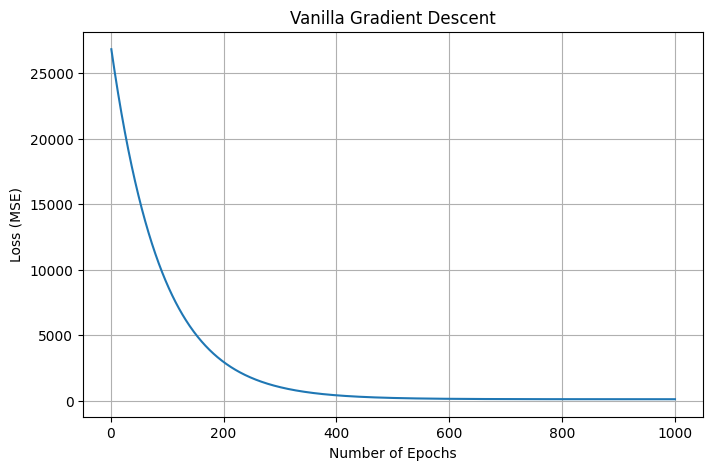

In [10]:
class VanillaGD:
  def __init__(self,rate = 0.0001, epochs = 1000):
    self.rate = rate
    self.epochs = epochs
    self.m = 0
    self.b = 0
    self.mse_history = []
  def predict(self, X):
    return self.m*X + self.b
  def fit(self, X, Y):
    n = len(X)
    for epoch in range(self.epochs):
      Y_pred = self.predict(X)
      dm = (-2/n)*np.sum(X*(Y-Y_pred))
      db = (-2/n)*np.sum(Y-Y_pred)
      self.m -= self.rate*dm
      self.b -= self.rate*db
      mse = np.mean((Y - self.predict(X))**2)
      self.mse_history.append(mse)

model = VanillaGD(rate = 0.000001, epochs = 1000)
model.fit(X,Y)

print("Slope =", model.m)
print("Intercept =", model.b)

plt.figure(figsize = (8,5))
plt.plot(range(1,model.epochs + 1), model.mse_history)
plt.xlabel("Number of Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Vanilla Gradient Descent")
plt.grid(True)
plt.show()

## Stochastic Gradient Descent (SGD) using OOP

SGD Slope = 3.098950729131612
SGD Intercept = 0.27688252336375146


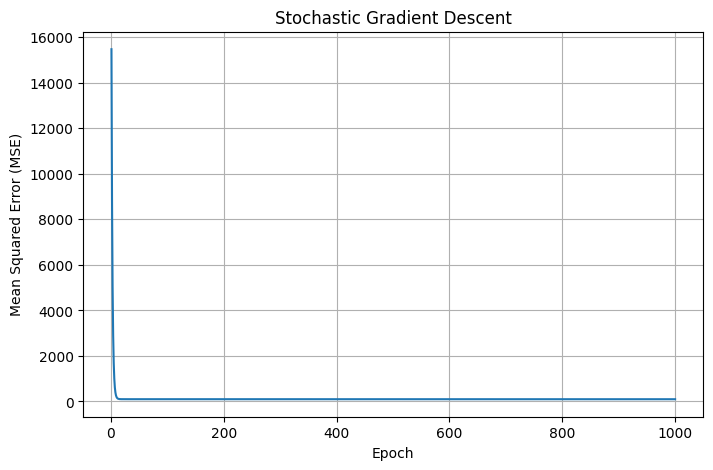

In [12]:
import numpy as np
import matplotlib.pyplot as plt

class SGD:
    def __init__(self, learning_rate=0.0001, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.m = 0
        self.b = 0
        self.mse_history = []

    def predict(self, X):
        return self.m * X + self.b

    def fit(self, X, Y):
        n = len(X)
        for epoch in range(self.epochs):
            indices = np.random.permutation(n)
            for i in indices:
                X_sample = X[i]
                Y_sample = Y[i]
                Y_pred = self.predict(X_sample)
                dm = -2 * X_sample * (Y_sample - Y_pred)
                db = -2 * (Y_sample - Y_pred)
                self.m -= self.learning_rate * dm
                self.b -= self.learning_rate * db
            Y_pred_full = self.predict(X)
            mse = np.mean((Y - Y_pred_full) ** 2)
            self.mse_history.append(mse)
        return self

sgd_model = SGD(learning_rate=0.000001, epochs=1000)
sgd_model.fit(X, Y)

print("SGD Slope =", sgd_model.m)
print("SGD Intercept =", sgd_model.b)

plt.figure(figsize=(8, 5))
plt.plot(range(1, sgd_model.epochs + 1), sgd_model.mse_history)
plt.xlabel("Number of Epochs")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Stochastic Gradient Descent")
plt.grid(True)
plt.show()

### Minibatch Gradient Descent using OOP

Mini-Batch GD Slope = 3.10474290069306
Mini-Batch GD Intercept = 0.06772718903943453


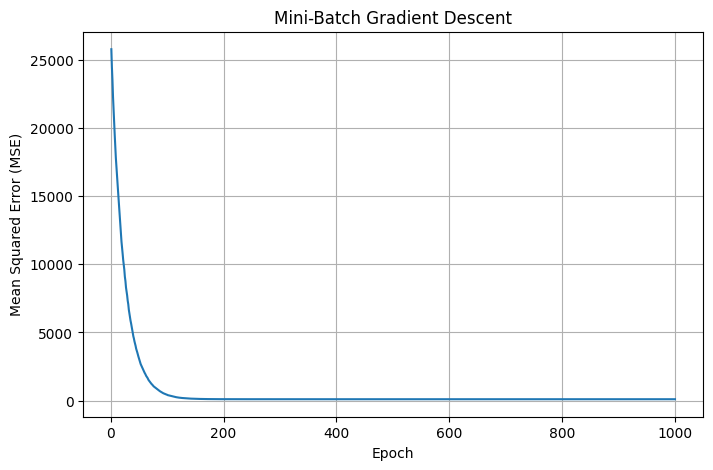

In [13]:
import numpy as np
import matplotlib.pyplot as plt

class MiniBatchGD:
    def __init__(self, learning_rate=0.0001, epochs=1000, batch_size=16):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.m = 0
        self.b = 0
        self.mse_history = []

    def predict(self, X):
        return self.m * X + self.b

    def fit(self, X, Y):
        n = len(X)
        for epoch in range(self.epochs):
            indices = np.random.permutation(n)
            X_shuffled = X[indices]
            Y_shuffled = Y[indices]
            for i in range(0, n, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                Y_batch = Y_shuffled[i:i+self.batch_size]
                Y_pred = self.predict(X_batch)
                batch_size = len(X_batch)
                dm = (-2/batch_size) * np.sum(X_batch * (Y_batch - Y_pred))
                db = (-2/batch_size) * np.sum(Y_batch - Y_pred)
                self.m -= self.learning_rate * dm
                self.b -= self.learning_rate * db
            Y_pred_full = self.predict(X)
            mse = np.mean((Y - Y_pred_full) ** 2)
            self.mse_history.append(mse)
        return self

mbgd_model = MiniBatchGD(learning_rate=0.000001, epochs=1000, batch_size=16)
mbgd_model.fit(X, Y)

print("Mini-Batch GD Slope =", mbgd_model.m)
print("Mini-Batch GD Intercept =", mbgd_model.b)

plt.figure(figsize=(8,5))
plt.plot(range(1, mbgd_model.epochs + 1), mbgd_model.mse_history)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Mini-Batch Gradient Descent")
plt.grid(True)
plt.show()